In [ ]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 48.8 MB/s eta 0:00:00


In [ ]:
!pip uninstall torch torchvision torchaudio
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

SyntaxError: invalid syntax (216900595.py, line 1)

In [ ]:
from ultralytics import YOLO

# Load pretrained YOLO-26 Nano
model_26n = YOLO("yolo26n.pt")

# Load pretrained YOLO-26 Small
model_26s = YOLO("yolo26s.pt")

# Load pretrained YOLO-26 Medium
model_26m = YOLO("yolo26m.pt")

# Load pretrained YOLO-26 Large
model_26l = YOLO("yolo26l.pt")

In [ ]:
import torch
from ultralytics import YOLO

# Benchmark helper from earlier
def benchmark_inference(model, input_data, num_runs=100, device='cuda'):
    # warm up
    for _ in range(5):
        model(input_data, device=device)

    times = []
    for _ in range(num_runs):
        start = torch.cuda.Event(enable_timing=True)
        end   = torch.cuda.Event(enable_timing=True)
        start.record()

        model(input_data, device=device)

        end.record()
        torch.cuda.synchronize()
        times.append(start.elapsed_time(end))

    mean_ms = sum(times) / len(times)
    fps = 1000 / mean_ms
    return {"mean_ms": mean_ms, "fps": fps}


# Load pretrained YOLO-26 models by name (automatically downloads)
model_26n = YOLO("yolo26n.pt")
model_26s = YOLO("yolo26s.pt")
model_26m = YOLO("yolo26m.pt")
model_26l = YOLO("yolo26l.pt")

print("Loaded YOLO-26 pretrained weights!")

# Create dummy input
input_tensor = torch.randn(1, 3, 640, 640).cuda()

# Benchmark
bench_26n = benchmark_inference(model_26n, input_tensor, device='cuda')
bench_26s = benchmark_inference(model_26s, input_tensor, device='cuda')
bench_26m = benchmark_inference(model_26m, input_tensor, device='cuda')
bench_26l = benchmark_inference(model_26l, input_tensor, device='cuda')

print(f"YOLO26n GPU: {bench_26n['mean_ms']:.1f} ms | {bench_26n['fps']:.1f} FPS")
print(f"YOLO26s GPU: {bench_26s['mean_ms']:.1f} ms | {bench_26s['fps']:.1f} FPS")
print(f"YOLO26m GPU: {bench_26m['mean_ms']:.1f} ms | {bench_26m['fps']:.1f} FPS")
print(f"YOLO26l GPU: {bench_26l['mean_ms']:.1f} ms | {bench_26l['fps']:.1f} FPS")

Loaded YOLO-26 pretrained weights!


AssertionError: Torch not compiled with CUDA enabled

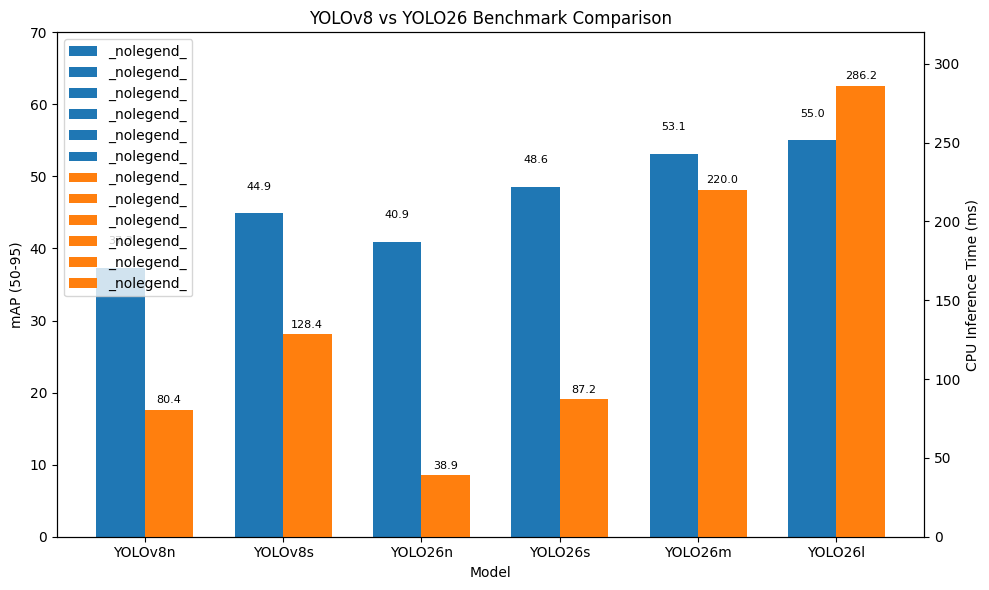

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example benchmark data (replace with your own metrics)
# mAP50-95 and CPU inference times on COCO (640px)
models = ["YOLOv8n", "YOLOv8s", "YOLO26n", "YOLO26s", "YOLO26m", "YOLO26l"]
mAP = [37.3, 44.9, 40.9, 48.6, 53.1, 55.0]        # mAP50-95 scores
cpu_latency = [80.4, 128.4, 38.9, 87.2, 220.0, 286.2]  # CPU inference ms

# Bar chart settings
x = np.arange(len(models))            # label locations
width = 0.35                         # bar width

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot mAP bars
bar1 = ax1.bar(x - width/2, mAP, width, label="mAP (50-95)", color="tab:blue")

# Create second y-axis for inference time
ax2 = ax1.twinx()
bar2 = ax2.bar(x + width/2, cpu_latency, width, label="CPU Latency (ms)", color="tab:orange")

# Labels and title
ax1.set_xlabel("Model")
ax1.set_ylabel("mAP (50-95)")
ax2.set_ylabel("CPU Inference Time (ms)")
ax1.set_title("YOLOv8 vs YOLO26 Benchmark Comparison")
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.set_ylim(0, 70)
ax2.set_ylim(0, 320)

# Add legends
bars = bar1 + bar2
labels = [b.get_label() for b in bars]
ax1.legend(bars, labels, loc="upper left")

# Display values on bars
def annotate_bars(bars, axis):
    for bar in bars:
        height = bar.get_height()
        axis.text(bar.get_x() + bar.get_width()/2, height + 3,
                  f"{height:.1f}", ha='center', va='bottom', fontsize=8)

annotate_bars(bar1, ax1)
annotate_bars(bar2, ax2)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Benchmark data from official YOLO-26 and YOLOv8 comparisons
# CPU ONNX inference time and COCO mAP @50–95
data = [
    {"model": "YOLOv8n", "mAP50-95": 37.3, "cpu_ms": 80.4},
    {"model": "YOLOv8s", "mAP50-95": 44.9, "cpu_ms": 128.4},
    {"model": "YOLOv8m", "mAP50-95": 50.5, "cpu_ms": 197.5},
    {"model": "YOLOv8x", "mAP50-95": 53.9, "cpu_ms": None},  # CPU often not reported
    {"model": "YOLO26n", "mAP50-95": 40.9, "cpu_ms": 38.9},
    {"model": "YOLO26s", "mAP50-95": 48.6, "cpu_ms": 87.2},
    {"model": "YOLO26m", "mAP50-95": 53.1, "cpu_ms": 220.0},
    {"model": "YOLO26l", "mAP50-95": 55.0, "cpu_ms": 286.2},
]

df = pd.DataFrame(data)

# Scatter plot: latency vs accuracy
fig_scatter = px.scatter(
    df.dropna(subset=["cpu_ms"]),
    x="cpu_ms",
    y="mAP50-95",
    text="model",
    color="model",
    size="mAP50-95",
    title="YOLOv8 vs YOLO-26: Accuracy (mAP) vs CPU Inference (ms)",
    labels={
        "cpu_ms": "CPU ONNX Inference Time (ms)",
        "mAP50-95": "COCO mAP (50–95)"
    },
    size_max=25
)

fig_scatter.update_traces(textposition="top center")
fig_scatter.update_layout(
    xaxis=dict(title="CPU Inference (ms, lower is faster)", type="log"),
    yaxis=dict(title="COCO mAP (50–95)"),
    legend_title="Model"
)

# Bar chart: mAP across models
fig_bar = go.Figure([
    go.Bar(
        x=df["model"],
        y=df["mAP50-95"],
        text=df["mAP50-95"],
        textposition="auto",
        marker=dict(color=["#1f77b4" if "v8" in m else "#ff7f0e" for m in df["model"]])
    )
])
fig_bar.update_layout(
    title="YOLO Model Accuracy (mAP 50–95)",
    xaxis_title="Model",
    yaxis_title="mAP (50–95)",
    yaxis=dict(range=[30, 60])
)

# Display
fig_scatter.show()
fig_bar.show()

In [ ]:
def benchmark_inference(model, num_runs=100, imgsz=640, device='cuda'):
    """
    Benchmark model inference speed.

    Returns:
        dict: Timing results in milliseconds
    """
    # Create dummy input
    dummy = np.random.randint(0, 255, (imgsz, imgsz, 3), dtype=np.uint8)

    # Warmup
    for _ in range(10):
        model(dummy, verbose=False, device=device)

    # Benchmark
    times = []
    for _ in range(num_runs):
        start = time.perf_counter()
        model(dummy, verbose=False, device=device)
        times.append((time.perf_counter() - start) * 1000)

    times = np.array(times)
    return {
        'mean_ms': np.mean(times),
        'std_ms': np.std(times),
        'min_ms': np.min(times),
        'max_ms': np.max(times),
        'fps': 1000 / np.mean(times)
    }

In [ ]:
print("Benchmarking on GPU...\n")

bench_26_gpu = benchmark_inference(yolo26_best, num_runs=100, device='cuda')
bench_11_gpu = benchmark_inference(yolo11_best, num_runs=100, device='cuda')

print(f"YOLO26 (GPU): {bench_26_gpu['mean_ms']:.2f} ± {bench_26_gpu['std_ms']:.2f} ms ({bench_26_gpu['fps']:.1f} FPS)")
print(f"YOLO11 (GPU): {bench_11_gpu['mean_ms']:.2f} ± {bench_11_gpu['std_ms']:.2f} ms ({bench_11_gpu['fps']:.1f} FPS)")

gpu_speedup = bench_11_gpu['mean_ms'] / bench_26_gpu['mean_ms']
print(f"\nGPU Speedup: {(gpu_speedup-1)*100:.1f}% faster")

Benchmarking on GPU...



NameError: name 'yolo26_best' is not defined

NameError: name 'metrics_26' is not defined

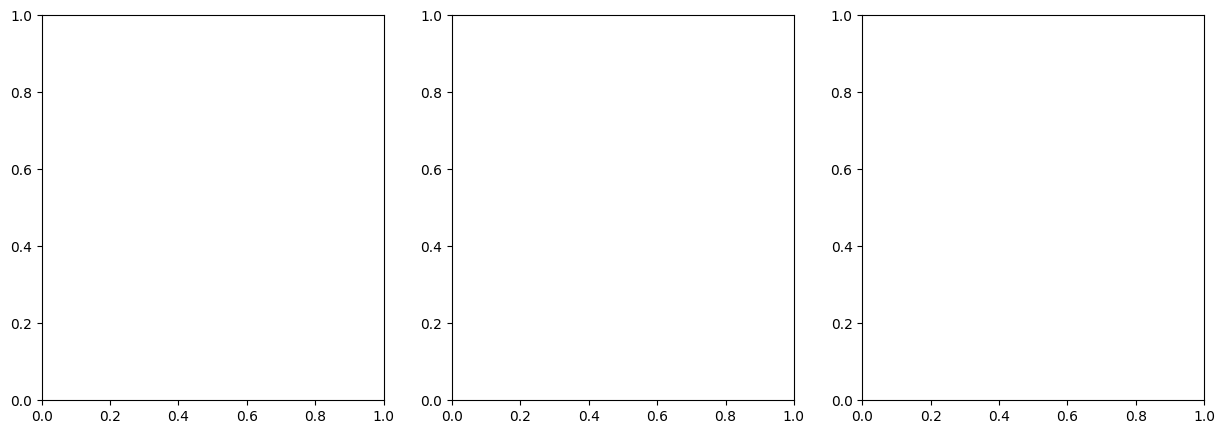

In [ ]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Accuracy comparison
models = ['YOLO26n', 'YOLO11n']
map50 = [metrics_26.box.map50, metrics_11.box.map50]
map5095 = [metrics_26.box.map, metrics_11.box.map]

x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width/2, map50, width, label='mAP50', color='#2ecc71')
axes[0].bar(x + width/2, map5095, width, label='mAP50-95', color='#3498db')
axes[0].set_ylabel('mAP')
axes[0].set_title('Accuracy Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()
axes[0].set_ylim(0, 1)

# GPU Speed
gpu_times = [bench_26_gpu['mean_ms'], bench_11_gpu['mean_ms']]
colors = ['#e74c3c' if t > min(gpu_times) else '#2ecc71' for t in gpu_times]
axes[1].bar(models, gpu_times, color=colors)
axes[1].set_ylabel('Inference Time (ms)')
axes[1].set_title('GPU Speed (lower is better)')
for i, v in enumerate(gpu_times):
    axes[1].text(i, v + 0.5, f'{v:.1f}ms', ha='center')

# CPU Speed
cpu_times = [bench_26_cpu['mean_ms'], bench_11_cpu['mean_ms']]
colors = ['#e74c3c' if t > min(cpu_times) else '#2ecc71' for t in cpu_times]
axes[2].bar(models, cpu_times, color=colors)
axes[2].set_ylabel('Inference Time (ms)')
axes[2].set_title('CPU Speed (lower is better)')
for i, v in enumerate(cpu_times):
    axes[2].text(i, v + 1, f'{v:.1f}ms', ha='center')

plt.tight_layout()
plt.savefig('benchmark_results.png', dpi=150, bbox_inches='tight')
plt.show()